In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH    = r"C:\Users\Mayank Joshi\Downloads\Marketing_Channel_Project\data"
OUTPUT_PATH  = os.path.join(DATA_PATH, 'funnel_analysis')
os.makedirs(OUTPUT_PATH, exist_ok=True)

master = pd.read_csv(os.path.join(DATA_PATH, 'master_table.csv'))
master['first_contact_date'] = pd.to_datetime(master['first_contact_date'], errors='coerce')
master['won_date']           = pd.to_datetime(master['won_date'], errors='coerce')
master['contact_month']      = master['first_contact_date'].dt.to_period('M')

print(f"Master table loaded : {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"Output folder ready : {OUTPUT_PATH}")

Master table loaded : 8,000 rows x 30 columns
Output folder ready : C:\Users\Mayank Joshi\Downloads\Marketing_Channel_Project\data\funnel_analysis


In [2]:
# Reconstruct every funnel stage from the data
total_leads        = len(master)
leads_with_date    = master['first_contact_date'].notna().sum()
converted          = master['converted'].sum()
sellers_with_orders = (master['total_orders'] > 0).sum()
sellers_repeat     = (master['total_orders'] >= 3).sum()

funnel_stages = pd.DataFrame({
    'stage':       ['Leads generated', 'Leads with contact date',
                    'Closed deals', 'Made first order', 'Repeat seller (3+ orders)'],
    'count':       [total_leads, leads_with_date, converted,
                    sellers_with_orders, sellers_repeat],
    'stage_order': [1, 2, 3, 4, 5]
})

funnel_stages['pct_of_total']    = (funnel_stages['count'] / total_leads * 100).round(2)
funnel_stages['pct_of_previous'] = funnel_stages['count'].pct_change() * 100
funnel_stages['pct_of_previous'] = funnel_stages['pct_of_previous'].round(2)
funnel_stages.loc[0, 'pct_of_previous'] = 100.0
funnel_stages['drop_off'] = funnel_stages['count'].shift(1) - funnel_stages['count']
funnel_stages.loc[0, 'drop_off'] = 0

print("FULL FUNNEL — VOLUME ANALYSIS")
print("=" * 70)
print(f"\n{'Stage':<30} {'Count':>8} {'% of Total':>12} {'% of Prev':>12} {'Drop-off':>10}")
print("-" * 70)
for _, row in funnel_stages.iterrows():
    drop = f"{int(row['drop_off']):,}" if row['drop_off'] > 0 else "-"
    print(f"  {row['stage']:<28} {int(row['count']):>8,} "
          f"{row['pct_of_total']:>11.1f}% "
          f"{row['pct_of_previous']:>11.1f}% "
          f"{drop:>10}")

print(f"\nKey insight: {round((1 - sellers_with_orders/converted)*100, 1)}% of converted sellers"
      f" never placed a single order (activation gap)")

FULL FUNNEL — VOLUME ANALYSIS

Stage                             Count   % of Total    % of Prev   Drop-off
----------------------------------------------------------------------
  Leads generated                 8,000       100.0%       100.0%          -
  Leads with contact date         3,058        38.2%       -61.8%      4,942
  Closed deals                      842        10.5%       -72.5%      2,216
  Made first order                  380         4.8%       -54.9%        462
  Repeat seller (3+ orders)         252         3.1%       -33.7%        128

Key insight: 54.9% of converted sellers never placed a single order (activation gap)


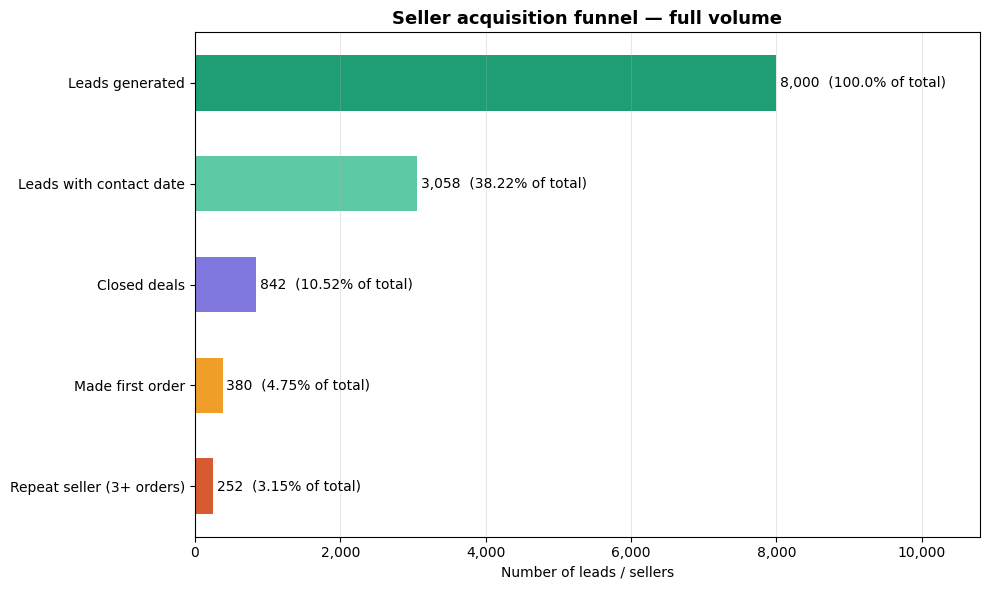

Chart saved


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1D9E75', '#5DCAA5', '#7F77DD', '#EF9F27', '#D85A30']
bars   = ax.barh(funnel_stages['stage'][::-1],
                 funnel_stages['count'][::-1],
                 color=colors[::-1], height=0.55)

for bar, (_, row) in zip(bars, funnel_stages[::-1].iterrows()):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{int(row['count']):,}  ({row['pct_of_total']}% of total)",
            va='center', fontsize=10)

ax.set_xlabel('Number of leads / sellers')
ax.set_title('Seller acquisition funnel — full volume', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, total_leads * 1.35)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'funnel_volume.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [4]:
channel_funnel = (
    master.groupby('origin')
    .agg(
        total_leads       = ('mql_id', 'count'),
        converted         = ('converted', 'sum'),
        activated         = ('total_orders', lambda x: (x > 0).sum()),
        repeat_sellers    = ('total_orders', lambda x: (x >= 3).sum()),
        total_revenue     = ('total_revenue', 'sum'),
        avg_days_convert  = ('days_to_convert', 'mean')
    )
    .reset_index()
)

channel_funnel['cvr']               = (channel_funnel['converted'] / channel_funnel['total_leads'] * 100).round(1)
channel_funnel['activation_rate']   = (channel_funnel['activated'] / channel_funnel['converted'].replace(0, np.nan) * 100).round(1)
channel_funnel['repeat_rate']       = (channel_funnel['repeat_sellers'] / channel_funnel['activated'].replace(0, np.nan) * 100).round(1)
channel_funnel['revenue_per_lead']  = (channel_funnel['total_revenue'] / channel_funnel['total_leads']).round(2)
channel_funnel = channel_funnel.sort_values('cvr', ascending=False)

print("FUNNEL BY CHANNEL — END TO END")
print("=" * 95)
print(f"\n{'Channel':<22} {'Leads':>7} {'Conv':>6} {'CVR%':>6} {'Active':>7} "
      f"{'Act%':>6} {'Repeat':>7} {'Rep%':>6} {'Rev/Lead':>10}")
print("-" * 95)
for _, row in channel_funnel.iterrows():
    act_rate = f"{row['activation_rate']:.0f}%" if not np.isnan(row['activation_rate']) else "n/a"
    rep_rate = f"{row['repeat_rate']:.0f}%"     if not np.isnan(row['repeat_rate'])     else "n/a"
    print(f"  {row['origin']:<20} {int(row['total_leads']):>7,} "
          f"{int(row['converted']):>6} {row['cvr']:>5.1f}% "
          f"{int(row['activated']):>7} {act_rate:>6} "
          f"{int(row['repeat_sellers']):>7} {rep_rate:>6} "
          f"${row['revenue_per_lead']:>8,.2f}")

channel_funnel.to_csv(os.path.join(OUTPUT_PATH, 'channel_funnel.csv'), index=False)
print(f"\nchannel_funnel.csv saved")

FUNNEL BY CHANNEL — END TO END

Channel                  Leads   Conv   CVR%  Active   Act%  Repeat   Rep%   Rev/Lead
-----------------------------------------------------------------------------------------------
  unknown                1,159    193  16.7%      85    44%      57    67% $  185.49
  paid_search            1,586    195  12.3%     101    52%      63    62% $   97.90
  organic_search         2,296    271  11.8%     113    42%      77    68% $   90.17
  direct_traffic           499     56  11.2%      31    55%      22    71% $   43.90
  referral                 284     24   8.5%       9    38%       6    67% $   62.98
  social                 1,350     75   5.6%      31    41%      21    68% $   32.21
  display                  118      6   5.1%       2    33%       1    50% $    7.82
  other_publicities         65      3   4.6%       0     0%       0    n/a $    0.00
  email                    493     15   3.0%       6    40%       3    50% $   17.21
  other              

In [5]:
# Only use leads where we have a contact date
cohort = master[master['first_contact_date'].notna()].copy()
cohort['contact_month'] = cohort['first_contact_date'].dt.to_period('M')

monthly_cohort = (
    cohort.groupby('contact_month')
    .agg(
        leads      = ('mql_id', 'count'),
        converted  = ('converted', 'sum'),
        revenue    = ('total_revenue', 'sum')
    )
    .reset_index()
)

monthly_cohort['cvr']             = (monthly_cohort['converted'] / monthly_cohort['leads'] * 100).round(2)
monthly_cohort['revenue_per_lead'] = (monthly_cohort['revenue'] / monthly_cohort['leads']).round(2)
monthly_cohort['contact_month_str'] = monthly_cohort['contact_month'].astype(str)

print("COHORT ANALYSIS — MONTHLY CONVERSION RATES")
print("=" * 65)
print(f"\n{'Month':<12} {'Leads':>8} {'Converted':>10} {'CVR%':>8} {'Revenue':>12} {'Rev/Lead':>10}")
print("-" * 65)
for _, row in monthly_cohort.iterrows():
    print(f"  {str(row['contact_month']):<10} {int(row['leads']):>8,} "
          f"{int(row['converted']):>10} {row['cvr']:>7.1f}% "
          f"${row['revenue']:>10,.0f} ${row['revenue_per_lead']:>8,.2f}")

COHORT ANALYSIS — MONTHLY CONVERSION RATES

Month           Leads  Converted     CVR%      Revenue   Rev/Lead
-----------------------------------------------------------------
  2017-01          76          3     4.0% $     2,369 $   31.17
  2017-02          39          1     2.6% $       313 $    8.03
  2017-03          49          0     0.0% $         0 $    0.00
  2017-04          59          1     1.7% $         0 $    0.00
  2017-05          52          1     1.9% $         0 $    0.00
  2017-06          76          0     0.0% $         0 $    0.00
  2017-07          66          3     4.5% $       605 $    9.16
  2017-08          42          2     4.8% $         0 $    0.00
  2017-09          49          1     2.0% $       574 $   11.70
  2017-10          79          4     5.1% $        90 $    1.14
  2017-11          51          2     3.9% $         0 $    0.00
  2017-12          45          1     2.2% $         0 $    0.00
  2018-01         139         11     7.9% $     3,149 $ 

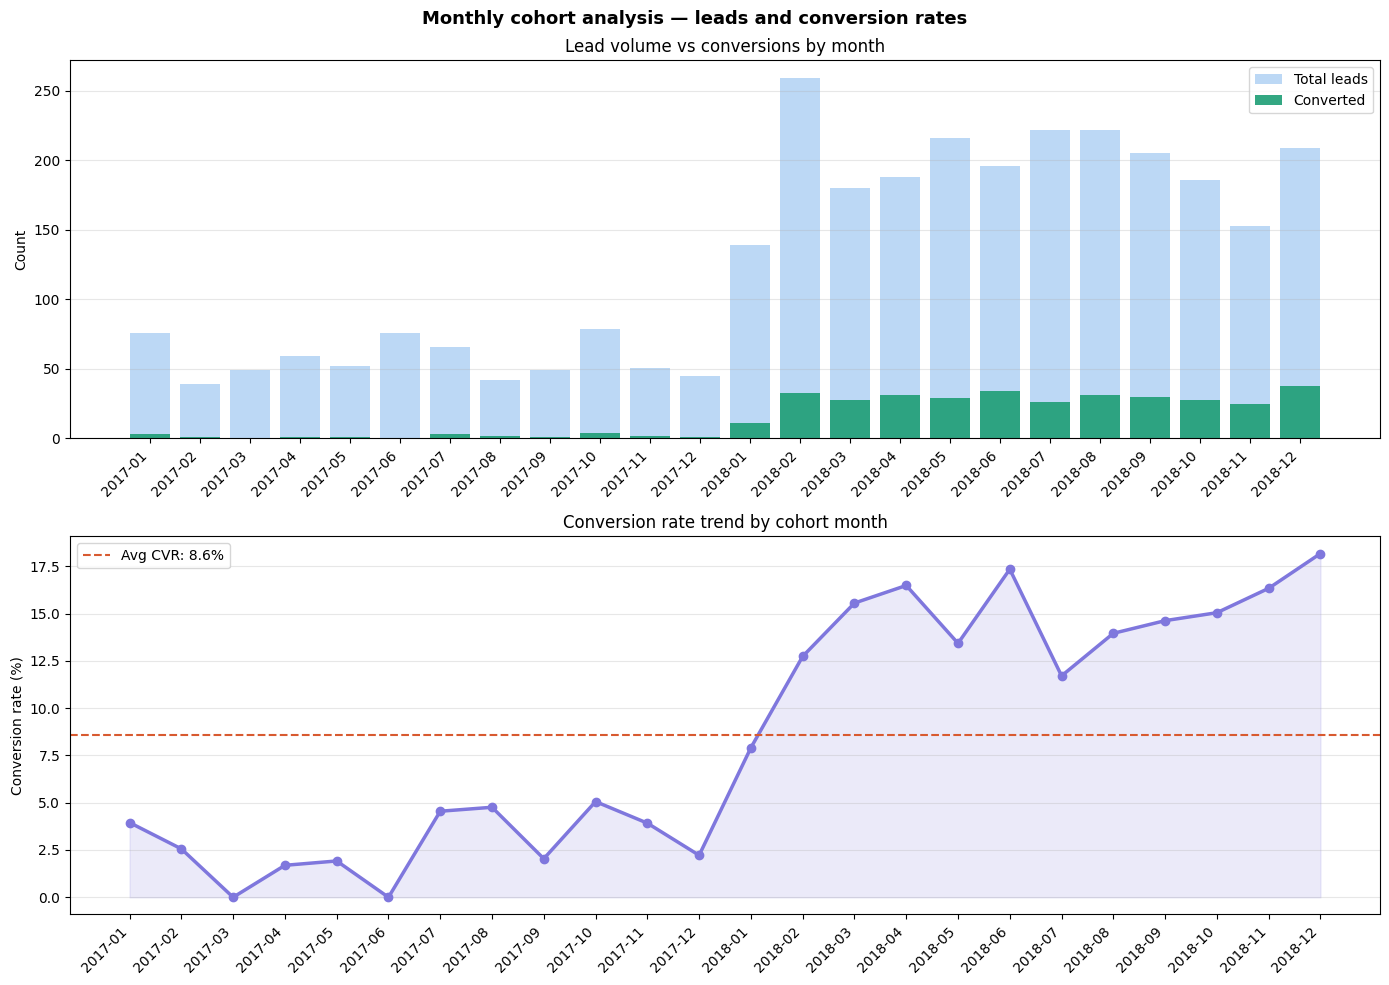

Chart saved


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Monthly cohort analysis — leads and conversion rates', fontsize=13, fontweight='bold')

x = range(len(monthly_cohort))

# Plot 1 — lead volume and conversions per month
axes[0].bar(x, monthly_cohort['leads'],     label='Total leads',  color='#B5D4F4', alpha=0.9)
axes[0].bar(x, monthly_cohort['converted'], label='Converted',    color='#1D9E75', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(monthly_cohort['contact_month_str'], rotation=45, ha='right')
axes[0].set_ylabel('Count')
axes[0].set_title('Lead volume vs conversions by month')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — CVR trend over time
axes[1].plot(x, monthly_cohort['cvr'], color='#7F77DD', linewidth=2.5, marker='o', markersize=6)
axes[1].fill_between(x, monthly_cohort['cvr'], alpha=0.15, color='#7F77DD')
axes[1].axhline(y=monthly_cohort['cvr'].mean(), color='#D85A30', linestyle='--',
                linewidth=1.5, label=f"Avg CVR: {monthly_cohort['cvr'].mean():.1f}%")
axes[1].set_xticks(x)
axes[1].set_xticklabels(monthly_cohort['contact_month_str'], rotation=45, ha='right')
axes[1].set_ylabel('Conversion rate (%)')
axes[1].set_title('Conversion rate trend by cohort month')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'cohort_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [7]:
# Treat each landing_page_id as a variant in a natural experiment
# Test: does landing page significantly affect conversion rate?

landing_pages = (
    master.groupby('landing_page_id')
    .agg(
        total_leads  = ('mql_id', 'count'),
        conversions  = ('converted', 'sum')
    )
    .reset_index()
)

landing_pages['cvr']          = (landing_pages['conversions'] / landing_pages['total_leads'] * 100).round(2)
landing_pages['non_converted'] = landing_pages['total_leads'] - landing_pages['conversions']

# Only keep pages with enough traffic for statistical significance (min 30 leads)
landing_pages = landing_pages[landing_pages['total_leads'] >= 30].sort_values('cvr', ascending=False)

print("LANDING PAGE EXPERIMENT — NATURAL A/B TEST")
print("=" * 70)
print(f"\n{'Landing Page':<38} {'Leads':>7} {'Conv':>6} {'CVR%':>8}")
print("-" * 70)
for _, row in landing_pages.iterrows():
    bar = '#' * int(row['cvr'])
    print(f"  {row['landing_page_id']:<36} {int(row['total_leads']):>7,} "
          f"{int(row['conversions']):>6} {row['cvr']:>7.1f}%  {bar}")

# Chi-square test — are conversion rate differences statistically significant?
contingency = landing_pages[['conversions', 'non_converted']].values
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square test across all landing pages:")
print(f"  Chi2 statistic : {chi2:.4f}")
print(f"  Degrees of freedom : {dof}")
print(f"  p-value        : {p_value:.6f}")
print(f"\n  Result: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} at 95% confidence")
print(f"  {'Landing pages have meaningfully different conversion rates.' if p_value < 0.05 else 'No significant difference between landing pages.'}")

LANDING PAGE EXPERIMENT — NATURAL A/B TEST

Landing Page                             Leads   Conv     CVR%
----------------------------------------------------------------------
  30077c17f2ec5010a82e37ad8925b95f          48     10    20.8%  ####################
  40dec9f3d5259a3d2dbcdab2114fae47         330     67    20.3%  ####################
  22c29808c4f815213303f8933030604c         883    174    19.7%  ###################
  b76ef37428e6799c421989521c0e5077         912    171    18.8%  ##################
  d83b0d0e48c8447d1d5507a44027a955          34      6    17.6%  #################
  7fa6214d82e911d070f51ef79381b956          68     11    16.2%  ################
  ce1a65abd0973638f1c887a6efcfa82d         394     59    15.0%  ##############
  b48ec5f3b04e9068441002a19df93c6c          51      7    13.7%  #############
  35c9b150ab36fe584c1f24fd458c453a          59      8    13.6%  #############
  241f79c7a8fe0270f4fb79fcbbcd17ad         109     14    12.8%  ############
  1ceb590c

DAYS TO CONVERT — DISTRIBUTION

  Total converted with timing data : 126
  Mean days to convert             : 109 days
  Median days to convert           : 66 days
  Fastest                          : 1 days
  Slowest                          : 588 days

  Conversion speed breakdown:
    0-30 days         28  (22.2%)  ######################
    31-60 days        29  (23.0%)  #######################
    61-90 days        19  (15.1%)  ###############
    91-180 days       22  (17.5%)  #################
    181-365 days      21  (16.7%)  ################
    365+ days          7  (5.6%)  #####


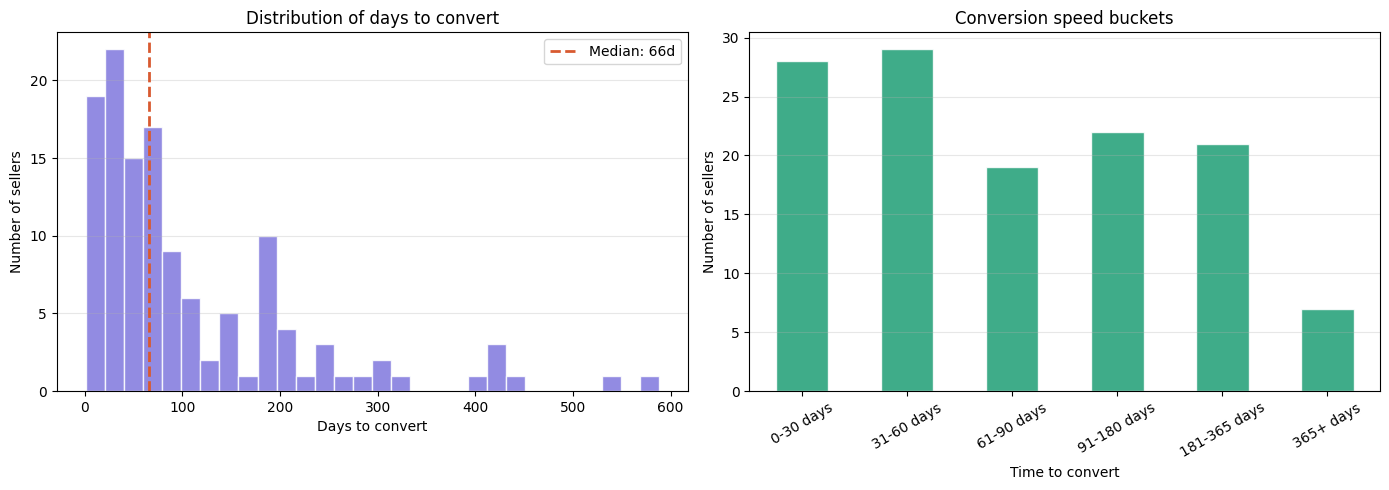

Chart saved


In [8]:
converted_timed = master[
    (master['converted'] == 1) &
    (master['days_to_convert'].notna()) &
    (master['days_to_convert'] > 0)
].copy()

print("DAYS TO CONVERT — DISTRIBUTION")
print("=" * 45)
print(f"\n  Total converted with timing data : {len(converted_timed):,}")
print(f"  Mean days to convert             : {converted_timed['days_to_convert'].mean():.0f} days")
print(f"  Median days to convert           : {converted_timed['days_to_convert'].median():.0f} days")
print(f"  Fastest                          : {converted_timed['days_to_convert'].min():.0f} days")
print(f"  Slowest                          : {converted_timed['days_to_convert'].max():.0f} days")

buckets = [0, 30, 60, 90, 180, 365, 999]
labels  = ['0-30 days', '31-60 days', '61-90 days', '91-180 days', '181-365 days', '365+ days']
converted_timed['time_bucket'] = pd.cut(converted_timed['days_to_convert'], bins=buckets, labels=labels)

bucket_counts = converted_timed['time_bucket'].value_counts().sort_index()
print(f"\n  Conversion speed breakdown:")
for bucket, count in bucket_counts.items():
    pct = round(count / len(converted_timed) * 100, 1)
    bar = '#' * int(pct)
    print(f"    {bucket:<15} {count:>4}  ({pct}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(converted_timed['days_to_convert'], bins=30, color='#7F77DD', alpha=0.85, edgecolor='white')
axes[0].axvline(converted_timed['days_to_convert'].median(), color='#D85A30',
                linestyle='--', linewidth=2, label=f"Median: {converted_timed['days_to_convert'].median():.0f}d")
axes[0].set_xlabel('Days to convert')
axes[0].set_ylabel('Number of sellers')
axes[0].set_title('Distribution of days to convert')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

bucket_counts.plot(kind='bar', ax=axes[1], color='#1D9E75', alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Time to convert')
axes[1].set_ylabel('Number of sellers')
axes[1].set_title('Conversion speed buckets')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'days_to_convert.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [9]:
# Save all tables
funnel_stages.to_csv(os.path.join(OUTPUT_PATH, 'funnel_volume.csv'), index=False)
monthly_cohort.to_csv(os.path.join(OUTPUT_PATH, 'cohort_monthly.csv'), index=False)
landing_pages.to_csv(os.path.join(OUTPUT_PATH, 'landing_page_experiment.csv'), index=False)

print("STAGE 3 COMPLETE — ALL OUTPUTS SAVED")
print("=" * 45)
print(f"\n  funnel_volume.csv")
print(f"  channel_funnel.csv")
print(f"  cohort_monthly.csv")
print(f"  landing_page_experiment.csv")
print(f"  funnel_volume.png")
print(f"  cohort_analysis.png")
print(f"  days_to_convert.png")
print(f"\nReady for Stage 4 — CAC / LTV modeling")

STAGE 3 COMPLETE — ALL OUTPUTS SAVED

  funnel_volume.csv
  channel_funnel.csv
  cohort_monthly.csv
  landing_page_experiment.csv
  funnel_volume.png
  cohort_analysis.png
  days_to_convert.png

Ready for Stage 4 — CAC / LTV modeling


In [10]:
# For each channel, which landing pages does it use and how do they convert?
channel_page = (
    master.groupby(['origin', 'landing_page_id'])
    .agg(
        leads       = ('mql_id', 'count'),
        conversions = ('converted', 'sum'),
        revenue     = ('total_revenue', 'sum')
    )
    .reset_index()
)

channel_page['cvr']           = (channel_page['conversions'] / channel_page['leads'] * 100).round(1)
channel_page['revenue_per_lead'] = (channel_page['revenue'] / channel_page['leads']).round(2)

# Only keep combinations with enough traffic to be meaningful
channel_page = channel_page[channel_page['leads'] >= 20].sort_values(
    ['origin', 'cvr'], ascending=[True, False]
)

print("CHANNEL x LANDING PAGE — CONVERSION BREAKDOWN")
print("=" * 80)

for channel, group in channel_page.groupby('origin'):
    avg_cvr = (group['conversions'].sum() / group['leads'].sum() * 100)
    print(f"\n  {channel.upper()}  (avg CVR: {avg_cvr:.1f}%)")
    print(f"  {'Landing Page':<38} {'Leads':>7} {'Conv':>6} {'CVR%':>7} {'Rev/Lead':>10}")
    print(f"  {'-'*68}")
    for _, row in group.iterrows():
        flag = '  <- best' if row['cvr'] == group['cvr'].max() else ''
        flag = '  <- worst' if row['cvr'] == group['cvr'].min() and len(group) > 1 else flag
        print(f"  {row['landing_page_id']:<38} {int(row['leads']):>7,} "
              f"{int(row['conversions']):>6} {row['cvr']:>6.1f}% "
              f"${row['revenue_per_lead']:>8,.2f}{flag}")

channel_page.to_csv(os.path.join(OUTPUT_PATH, 'channel_landing_page_matrix.csv'), index=False)
print(f"\nchannel_landing_page_matrix.csv saved")

CHANNEL x LANDING PAGE — CONVERSION BREAKDOWN

  DIRECT_TRAFFIC  (avg CVR: 15.4%)
  Landing Page                             Leads   Conv    CVR%   Rev/Lead
  --------------------------------------------------------------------
  ce1a65abd0973638f1c887a6efcfa82d            46     11   23.9% $  104.92  <- best
  22c29808c4f815213303f8933030604c           105     18   17.1% $   45.39
  b76ef37428e6799c421989521c0e5077            25      4   16.0% $    3.56
  7fa6214d82e911d070f51ef79381b956            22      3   13.6% $   32.04
  e492ee5eaf1697716985cc6f33f9cd9b            22      1    4.5% $    0.00
  f017be4dbf86243af5c1ebed0cff36a2            20      0    0.0% $    0.00  <- worst

  DISPLAY  (avg CVR: 7.4%)
  Landing Page                             Leads   Conv    CVR%   Rev/Lead
  --------------------------------------------------------------------
  a7982125ff7aa3b2054c6e44f9d28522            27      2    7.4% $    0.00  <- best

  EMAIL  (avg CVR: 3.5%)
  Landing Page            

In [12]:
page_performance = (
    master.groupby('landing_page_id')
    .agg(leads=('mql_id','count'), conversions=('converted','sum'))
    .reset_index()
)
page_performance['cvr'] = (
    page_performance['conversions'] / page_performance['leads'] * 100
).round(1)

# Only classify pages with enough traffic to matter
page_performance_filtered = page_performance[page_performance['leads'] >= 20].copy()

# Use actual CVR values to set thresholds — not quantiles on zero-heavy data
sorted_cvrs = page_performance_filtered['cvr'].sort_values()
n = len(sorted_cvrs)
low_threshold  = sorted_cvrs.iloc[n // 3]
high_threshold = sorted_cvrs.iloc[(2 * n) // 3]

# If thresholds collapse (too many zeros) — use fixed meaningful cutoffs
if high_threshold == low_threshold:
    low_threshold  = page_performance_filtered['cvr'].median() * 0.6
    high_threshold = page_performance_filtered['cvr'].median() * 1.4

def classify_page(cvr):
    if cvr >= high_threshold: return 'top_performer'
    elif cvr >= low_threshold: return 'mid_performer'
    else: return 'low_performer'

page_performance_filtered['page_tier'] = page_performance_filtered['cvr'].apply(classify_page)

print(f"Page tier thresholds (based on {len(page_performance_filtered)} pages with 20+ leads):")
print(f"  Top performer  : CVR >= {high_threshold:.1f}%")
print(f"  Mid performer  : CVR {low_threshold:.1f}% to {high_threshold:.1f}%")
print(f"  Low performer  : CVR < {low_threshold:.1f}%")

tier_counts = page_performance_filtered['page_tier'].value_counts()
print(f"\n  Top pages  : {tier_counts.get('top_performer', 0)}")
print(f"  Mid pages  : {tier_counts.get('mid_performer', 0)}")
print(f"  Low pages  : {tier_counts.get('low_performer', 0)}")

# Join tier back to master
master_with_tier = master.merge(
    page_performance_filtered[['landing_page_id', 'page_tier', 'cvr']]
    .rename(columns={'cvr': 'page_cvr'}),
    on='landing_page_id', how='left'
)
master_with_tier['page_tier'] = master_with_tier['page_tier'].fillna('low_performer')

# For each channel what % of traffic goes to each tier
channel_tier = (
    master_with_tier.groupby(['origin', 'page_tier'])
    .agg(leads=('mql_id','count'), conversions=('converted','sum'))
    .reset_index()
)

channel_totals = master_with_tier.groupby('origin')['mql_id'].count().reset_index()
channel_totals.columns = ['origin', 'total_leads']
channel_tier = channel_tier.merge(channel_totals, on='origin')
channel_tier['pct_of_channel_traffic'] = (
    channel_tier['leads'] / channel_tier['total_leads'] * 100
).round(1)

print(f"\nCHANNEL TRAFFIC DISTRIBUTION ACROSS PAGE TIERS")
print("=" * 75)
print(f"\n{'Channel':<22} {'Top page %':>12} {'Mid page %':>12} {'Low page %':>12}  Verdict")
print("-" * 75)

for channel in master['origin'].value_counts().index.tolist():
    subset = channel_tier[channel_tier['origin'] == channel]
    top = subset[subset['page_tier']=='top_performer']['pct_of_channel_traffic'].sum()
    mid = subset[subset['page_tier']=='mid_performer']['pct_of_channel_traffic'].sum()
    low = subset[subset['page_tier']=='low_performer']['pct_of_channel_traffic'].sum()

    if top >= 50:
        verdict = 'Well matched to good pages'
    elif low >= 50:
        verdict = 'MISMATCH — mostly on weak pages'
    else:
        verdict = 'Mixed — room to optimise'

    print(f"  {channel:<20} {top:>11.1f}% {mid:>11.1f}% {low:>11.1f}%  {verdict}")

# Highlight the biggest opportunity
mismatch_channels = []
for channel in master['origin'].value_counts().index.tolist():
    subset = channel_tier[channel_tier['origin'] == channel]
    low = subset[subset['page_tier']=='low_performer']['pct_of_channel_traffic'].sum()
    leads = master[master['origin']==channel].shape[0]
    mismatch_channels.append({'channel': channel, 'low_pct': low, 'leads': leads})

mismatch_df = pd.DataFrame(mismatch_channels).sort_values('low_pct', ascending=False)

print(f"\nBiggest reallocation opportunities:")
print(f"(leads currently on low-performing pages that could be redirected)")
print()
for _, row in mismatch_df[mismatch_df['low_pct'] > 20].iterrows():
    wasted_leads = int(row['leads'] * row['low_pct'] / 100)
    print(f"  {row['channel']:<22} {row['low_pct']:.1f}% on weak pages "
          f"= ~{wasted_leads:,} leads that could convert better")

channel_tier.to_csv(os.path.join(OUTPUT_PATH, 'channel_page_tier_analysis.csv'), index=False)
print(f"\nchannel_page_tier_analysis.csv saved")

Page tier thresholds (based on 64 pages with 20+ leads):
  Top performer  : CVR >= 10.0%
  Mid performer  : CVR 3.4% to 10.0%
  Low performer  : CVR < 3.4%

  Top pages  : 22
  Mid pages  : 22
  Low pages  : 20

CHANNEL TRAFFIC DISTRIBUTION ACROSS PAGE TIERS

Channel                  Top page %   Mid page %   Low page %  Verdict
---------------------------------------------------------------------------
  organic_search              52.7%        22.3%        25.0%  Well matched to good pages
  paid_search                 55.3%        19.0%        25.7%  Well matched to good pages
  social                       5.9%        75.9%        18.1%  Mixed — room to optimise
  unknown                     66.2%         9.6%        24.2%  Well matched to good pages
  direct_traffic              51.3%        18.4%        30.3%  Well matched to good pages
  email                        9.5%        25.2%        65.3%  MISMATCH — mostly on weak pages
  referral                    41.2%        28.2%  